# L10d: Face Arithmetic with Autoencoders
In this lab, we train a nonlinear autoencoder on the [Olivetti Faces dataset](https://scikit-learn.org/stable/datasets/real_world.html#olivetti-faces-dataset), a collection of 400 grayscale face images (40 subjects, 10 images each, each $64\times 64$ pixels). After training, we explore the learned latent space by interpolating between faces and performing latent space arithmetic, the face equivalent of the word vector analogies from L9a.

The idea is simple: if the autoencoder learns a structured latent space, then vector operations on the codes $\mathbf{z}$ should produce meaningful changes in the reconstructed faces. For example, if we compute the "glasses vector" by subtracting the code for a face without glasses from the code for the same face with glasses, we can add that vector to a new face to synthesize what that person might look like wearing glasses.

> __Learning Objectives__
>
> * __Understand autoencoder architecture and reconstruction:__ Describe the encoder-bottleneck-decoder structure and the MSE reconstruction loss. Explain how the bottleneck forces the network to learn a compressed representation of the input.
> * __Perform latent space arithmetic on images:__ Isolate facial attributes as directions in latent space and transfer them to new faces. Apply vector arithmetic to face embeddings using the same analogy structure as word2vec.
> * __Compare nonlinear autoencoders to PCA:__ Explain why a linear autoencoder recovers the PCA subspace. Evaluate the difference in reconstruction quality between a nonlinear autoencoder and PCA on face arithmetic tasks.

Let's get started!
___

## Background: What is an Autoencoder?
An autoencoder is a neural network trained to reconstruct its input through a bottleneck layer that has fewer nodes than the input. The network consists of two parts: an encoder $f_{\mathrm{enc}}:\mathbb{R}^{d_{\mathrm{in}}}\rightarrow\mathbb{R}^{d}$ that compresses the input into a low-dimensional code $\mathbf{z}\in\mathbb{R}^{d}$, and a decoder $f_{\mathrm{dec}}:\mathbb{R}^{d}\rightarrow\mathbb{R}^{d_{\mathrm{in}}}$ that reconstructs the input from that code, where $d < d_{\mathrm{in}}$ is the bottleneck dimension. The bottleneck forces the network to learn a compressed representation of the data. After training, the bottleneck activations serve as a learned embedding of the input, analogous to the word embeddings from L9a, but applicable to any data type.

<div>
  <center>
    <img src="figs/Fig-Autoencoder-Architecture.svg" style="width:80%" />
  </center>
</div>

> __Reconstruction loss:__
>
> The autoencoder is trained to minimize the mean squared error (MSE) between the input and its reconstruction over $N$ training examples:
> $$\mathcal{L}(\theta) = \frac{1}{N}\sum_{n=1}^{N}\|\mathbf{x}^{(n)} - \hat{\mathbf{x}}^{(n)}(\theta)\|_{2}^{2}$$
> where $\hat{\mathbf{x}}^{(n)}(\theta) = f_{\mathrm{dec}}(f_{\mathrm{enc}}(\mathbf{x}^{(n)}))$ is the reconstruction of input $\mathbf{x}^{(n)}$. The parameters $\theta$ are optimized using backpropagation and gradient descent. The only difference from a standard feedforward network is the training target: instead of predicting a label, the autoencoder predicts the input itself.

The choice of activation functions determines what an autoencoder can learn. When the encoder and decoder use no activation functions, the autoencoder reduces to a rank-$d$ linear projection, and the optimal solution recovers the same subspace as the top $d$ principal components from PCA (Baldi and Hornik, 1989). A linear autoencoder cannot learn anything that PCA does not already capture. Adding nonlinear activation functions (ReLU, sigmoid) allows the autoencoder to learn representations on curved manifolds that linear methods miss. Nonlinear activations let the encoder bend and reshape the input space before compressing it, so the bottleneck code $\mathbf{z}$ can preserve structure that PCA would destroy. In Task 3 below, we compare the autoencoder and PCA directly to see this difference.

If the autoencoder learns a structured latent space, then vector operations on the codes $\mathbf{z}$ produce meaningful changes in the reconstructed output. This is the same principle behind word2vec analogies from L9a. For example, if we compute a "glasses vector" by subtracting the code for a face without glasses from the code for the same face with glasses, we can add that vector to a new face to synthesize what that person might look like wearing glasses.

___

## Setup, Data, and Prerequisites
We set up the computational environment, load the Olivetti Faces dataset, build and train the autoencoder, and compute all the representations we need for the tasks below.

> __What is the `Include.jl` file?__
>
> The [`include(...)` command](https://docs.julialang.org/en/v1/base/base/#include) evaluates the contents of the input source file in the current module's global scope. The `Include.jl` file loads required packages and defines path constants.

Let's load the packages and paths.

In [1]:
include("Include.jl"); # load packages, paths, and local source files


SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up


In addition to standard Julia libraries, we'll also use [the `VLDataScienceMachineLearningPackage.jl` package](https://github.com/varnerlab/VLDataScienceMachineLearningPackage.jl). Check out [the documentation](https://varnerlab.github.io/VLDataScienceMachineLearningPackage.jl/dev/) for more information on the functions, types, and data used in this material.

### Constants
We define the hyperparameters and data dimensions used throughout the notebook: `d` (bottleneck dimension), `image_dim` (pixel width/height), `input_dim` (flattened image dimension), `n_subjects` and `n_per_subject` (dataset size), `η` (learning rate), `num_epochs` (training epochs), and `batch_size` (mini-batch size).

In [2]:
d, image_dim, input_dim, n_subjects, n_per_subject, η, num_epochs, batch_size = let
    d = 32;                 # bottleneck dimension
    image_dim = 64;         # each face is 64x64 pixels
    input_dim = 64 * 64;    # flattened image dimension (4096)
    n_subjects = 40;        # number of subjects in the dataset
    n_per_subject = 10;     # images per subject
    η = 1e-3;               # learning rate
    num_epochs = 200;       # training epochs
    batch_size = 32;        # mini-batch size

    (d, image_dim, input_dim, n_subjects, n_per_subject, η, num_epochs, batch_size)
end;

### Data
In this lab we use the [Olivetti Faces dataset](https://scikit-learn.org/stable/datasets/real_world.html#olivetti-faces-dataset) which contains 400 grayscale images of 40 subjects (10 images per subject). Each image is $64\times 64$ pixels with values in $[0,1]$. The images vary in lighting, facial expression, and whether the subject is wearing glasses. This cell produces `X`, a $4096\times 400$ matrix where each column is a flattened face image, and `y`, a length-400 vector of subject labels (integers $0$ through $39$).

In [3]:
X, y = let

    # load the face data and targets from CSV -
    faces_df = CSV.read(joinpath(_PATH_TO_DATA, "olivetti_faces.csv"), DataFrame; header=false);
    targets_df = CSV.read(joinpath(_PATH_TO_DATA, "olivetti_targets.csv"), DataFrame; header=false);

    # convert to matrices: X is (4096 x 400), each column is one face -
    X = Float32.(Matrix(faces_df)'); # face matrix (pixels x images)
    y = Int.(vec(Matrix(targets_df)));

    println("Face matrix size: $(size(X)) (pixels x images)");
    println("Subjects: $(length(unique(y))) with $(n_per_subject) images each");

    (X, y) # return the data and targets as a tuple
end;

UndefVarError: UndefVarError: `CSV` not defined in `Main`
Suggestion: check for spelling errors or missing imports.
Hint: CSV is loaded but not imported in the active module Main.

Let's visualize the first image of each of the 40 subjects.

In [4]:
let

    # initialize - 
    plots = []; # make an array to hold the face plots

    # go through each subject and plot the first image we find for that subject -
    for subject ∈ 0:39
        idx = findfirst(y .== subject);
        img = Gray.(reshape(X[:, idx], image_dim, image_dim)');
        push!(plots, heatmap(img, color=:grays, axis=false, ticks=false, 
            title="S$(subject)", titlefontsize=7, aspect_ratio=:equal));
    end
    plot(plots..., layout=(5, 8), size=(900, 600), margin=0Plots.mm) # make a grid of the first 40 faces
end

UndefVarError: UndefVarError: `y` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

### Build and Train the Autoencoder
We build a nonlinear autoencoder with a symmetric architecture. The encoder compresses each $4096$-dimensional face into a $d = 32$-dimensional bottleneck code, and the decoder mirrors the encoder to reconstruct the face from that code. If a pre-trained model exists on disk, we load it instead of retraining. During training, we checkpoint the best model (lowest loss) and restore it at the end. This cell produces four variables: `encoder`, the encoder network $f_{\mathrm{enc}}:\mathbb{R}^{4096}\rightarrow\mathbb{R}^{32}$; `decoder`, the decoder network $f_{\mathrm{dec}}:\mathbb{R}^{32}\rightarrow\mathbb{R}^{4096}$; `autoencoder`, the combined encoder-decoder chain; and `loss_history`, a vector of per-epoch average MSE loss values.

> __Architecture:__
>
> The encoder has layers $4096 \rightarrow 512 \rightarrow 128 \rightarrow 32$ and the decoder mirrors this as $32 \rightarrow 128 \rightarrow 512 \rightarrow 4096$. We use `relu` activations in hidden layers and `sigmoid` on the decoder output to keep pixel values in $[0,1]$. The model is trained by minimizing the MSE reconstruction loss $\mathcal{L}(\theta) = \frac{1}{N}\sum_{n=1}^{N}\|\mathbf{x}^{(n)} - \hat{\mathbf{x}}^{(n)}(\theta)\|_{2}^{2}$ using the Adam optimizer.

Let's build the encoder, decoder, and combined autoencoder model.

In [5]:
encoder, decoder, autoencoder, loss_history = let

    # build architecture - let's start with the encoder -
    encoder = Chain(
        Dense(input_dim, 512, relu),
        Dense(512, 128, relu),
        Dense(128, d)
    );

    # now the decoder - notice the symmetry with the encoder, but in reverse order
    decoder = Chain(
        Dense(d, 128, relu),
        Dense(128, 512, relu),
        Dense(512, input_dim, sigmoid) # the sigmoid activation at the end to constrain outputs to [0, 1] pixel range -
    );

    # the autoencoder is just the encoder followed by the decoder -
    autoencoder = Chain(encoder, decoder);
    n_params = sum(length, Flux.trainable(autoencoder));
    println("Encoder: $(input_dim) → 512 → 128 → $(d)"); # din -> bottleneck (latent space)
    println("Decoder: $(d) → 128 → 512 → $(input_dim)"); # bottleneck (latent space) -> din
    println("Total parameters: $(n_params)");

    # Main training loop - first, we check if a pre-trained model exists. 
    # If it does, we load it. If not, we train the autoencoder from scratch and save the best model for future use.
    # look for a pre-trained model file; if exists, load; if not, train -
    lh_ = nothing;
    model_path = joinpath(_PATH_TO_DATA, "autoencoder_d$(d).jld2");
    if isfile(model_path) == true # we have a pre-trained model, let's load it -
        println("Loading pre-trained model from $(model_path)");
        f = jldopen(model_path, "r");
        model_state = f["model_state"]; lh_ = f["loss_history"];
        close(f);
        Flux.loadmodel!(autoencoder, model_state);
        println("Model loaded successfully!");
    else

        # Ok, so if we get here we need to train the model from scratch. This is a bit more involved, so let's go through it step by step.
        println("Training autoencoder ($(num_epochs) epochs, $(size(X, 2)) samples)...");
        opt_state = Flux.setup(Adam(η), autoencoder); # setup the optimizer state for training (ADAM with learning rate η)
        lh_ = zeros(Float64, num_epochs); # allocate an array to hold the loss history for each epoch
        best_loss = Inf; # initially we don't have a best loss, so we set it to infinity
        best_state = Flux.state(autoencoder); # we will save the best model state here
        best_epoch = 0; # index of the epoch with the best model
        N = size(X, 2);

        for epoch in 1:num_epochs
            epoch_loss = 0.0;
            indices = shuffle(1:N);
            n_batches = 0;

            for start in 1:batch_size:N
                stop = min(start + batch_size - 1, N);
                batch = X[:, indices[start:stop]];

                loss, grads = Flux.withgradient(autoencoder) do model
                    x_hat = model(batch);
                    Flux.mse(x_hat, batch);
                end

                Flux.update!(opt_state, autoencoder, grads[1]);
                epoch_loss += loss;
                n_batches += 1;
            end

            lh_[epoch] = epoch_loss / n_batches;

            # checkpoint the best model -
            if lh_[epoch] < best_loss
                best_loss = lh_[epoch];
                best_state = deepcopy(Flux.state(autoencoder));
                best_epoch = epoch;
            end

            if epoch % 25 == 0 || epoch == 1
                println("Epoch $(lpad(epoch, 3)): loss = $(round(lh_[epoch], digits=6)) (best: $(round(best_loss, digits=6)) @ epoch $best_epoch)");
            end
        end

        # restore the best model weights -
        Flux.loadmodel!(autoencoder, best_state);
        println("Restored best model from epoch $best_epoch (loss: $(round(best_loss, digits=6)))");

        # save the best model for future use -
        jldsave(model_path; model_state=best_state, loss_history=lh_);
        println("Model saved to $(model_path)");
    end

    (encoder, decoder, autoencoder, lh_)
end;

Encoder: 4096 → 512 → 128 → 32
Decoder: 32 → 128 → 512 → 4096
Total parameters: 2
Loading pre-trained model from /Users/jdv27/Desktop/julia_work/CHEME-150-eCornell-Repository/courses/CHEME-155/module-6/data/autoencoder_d32.jld2
Model loaded successfully!


Let's plot the training loss to verify convergence.

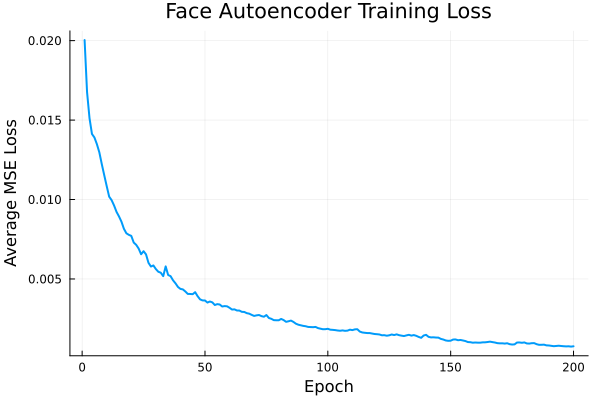

In [6]:
let
    plot(1:num_epochs, loss_history;
        xlabel="Epoch", ylabel="Average MSE Loss",
        title="Face Autoencoder Training Loss",
        legend=false, lw=2)
end

### Precompute Representations
We compute the latent code for every image (all 400) and the PCA projection for comparison in the tasks below. This cell produces four variables: `Z_all`, a $d\times 400$ matrix of autoencoder codes (one column per image); `V_d`, the $4096\times d$ matrix of top PCA basis vectors; `μ_pca`, the $4096\times 1$ pixel mean; and `Z_pca_all`, a $d\times 400$ matrix of PCA codes. To access the code for image $j$ of subject $s$, use the helper function `img_idx(s, j)` which returns the column index into `Z_all` or `Z_pca_all`.

In [7]:
Z_all, V_d, μ_pca, Z_pca_all = let

    # autoencoder codes for every image -
    Z = encoder(X);

    # PCA projection for comparison -
    X_f32 = Float32.(X);
    μ = mean(X_f32, dims=2);
    X_centered = X_f32 .- μ;

    U, S, V = svd(Float64.(X_centered)');
    V_d = Float32.(V[:, 1:d]);
    Z_pca = V_d' * X_centered;

    println("Variance explained by top $(d) PCs: $(round(100 * sum(S[1:d].^2) / sum(S.^2), digits=1))%");

    (Z, V_d, μ, Z_pca)
end;

# helper: given subject s (0-indexed) and image j (1-indexed within that subject),
# return the column index into Z_all or Z_pca_all.
img_idx(s, j) = findall(y .== s)[j];

UndefVarError: UndefVarError: `X` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

___

## Task 1: Reconstructions and Face Morphing
In this task, we check whether the autoencoder learned useful representations by examining reconstruction quality, then explore the smoothness of the latent space by interpolating between two faces. We'll start with a face - and then we'll take a linear path in latent space to another face, and see how the reconstruction changes along the way.

> __Reconstructions and interpolation:__
>
> If the autoencoder is working, the reconstructed faces should preserve identity even though they are blurrier than the originals. The blurriness comes from the MSE loss, which penalizes large pixel errors but not blurriness directly. If the latent space is smooth, a linear path between two codes $\mathbf{z}(\alpha) = (1 - \alpha)\mathbf{z}_A + \alpha\mathbf{z}_B$ should produce a gradual morph between two faces, not abrupt jumps.

Let's compare original and reconstructed faces for several subjects.

In [8]:
let

    # initialize - 
    subjects_to_show = [0, 5, 10, 15, 20, 25, 30, 35]; # let's pick a few subjects to visualize
    n = length(subjects_to_show); # how many subjects are we showing?
    plots = []; # allocate an array to hold the plots

    # let's iterate through the subjects, make the plot, and then store in the plots array -
    for subject ∈ subjects_to_show
        
        idx = findfirst(y .== subject); # what is the index of this image?

        # original -
        img_orig = Gray.(reshape(X[:, idx], image_dim, image_dim)');
        push!(plots, heatmap(img_orig, color=:grays, axis=false, ticks=false,
            title="S$(subject) orig", titlefontsize=7, aspect_ratio=:equal));

        # autoencoder reconstruction -
        x_hat = autoencoder(X[:, idx]);
        img_recon = Gray.(reshape(x_hat, image_dim, image_dim)');
        push!(plots, heatmap(img_recon, color=:grays, axis=false, ticks=false,
            title="S$(subject) AE", titlefontsize=7, aspect_ratio=:equal));

        # PCA reconstruction -
        z_pca = V_d' * (X[:, idx] .- μ_pca); # this is the PCA latent code for this image
        x_pca = clamp.(V_d * z_pca .+ μ_pca, 0f0, 1f0);
        img_pca = Gray.(reshape(x_pca, image_dim, image_dim)');
        push!(plots, heatmap(img_pca, color=:grays, axis=false, ticks=false,
            title="S$(subject) PCA", titlefontsize=7, aspect_ratio=:equal));
    end

    plot(plots..., layout=(n, 3), size=(450, 100 * n), margin=0Plots.mm) # make a grid of the original, autoencoder reconstruction, and PCA reconstruction for each subject
end

UndefVarError: UndefVarError: `y` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

Now let's morph between two subjects by linearly interpolating in latent space. We encode two faces to get $\mathbf{z}_A = f_{\mathrm{enc}}(\mathbf{x}_A)$ and $\mathbf{z}_B = f_{\mathrm{enc}}(\mathbf{x}_B)$, then decode points along the line $\mathbf{z}(\alpha) = (1-\alpha)\mathbf{z}_A + \alpha\mathbf{z}_B$ where $\alpha\in[0,1]$ controls the blend between the two faces. Try changing `subject_A` and `subject_B` to explore different pairs.

In [9]:
let

    # initialize -
    subject_A = 0; # this is the first subject we will interpolate from
    subject_B = 10; # this is the second subject we will interpolate to
    idx_A = findfirst(y .== subject_A); # we find the index of the first image of subject A
    idx_B = findfirst(y .== subject_B); # we find the index of the first image of subject B
    n_steps = 10; # how many interpolation steps to take between the two faces?
    alphas = range(0f0, 1f0, length=n_steps); # this is the interpolation parameter that goes from 0 to 1 (notice we use Float32 for the alphas to match the data type of the latent codes)
    plots = []; # allocate an array to hold the plots of the interpolated faces

    # we've already built the encoder and decoder, so we can just use those to get the latent codes for these two images -
    z_A = encoder(X[:, idx_A]); # this is the latent code for the first image of subject A
    z_B = encoder(X[:, idx_B]); # this is the latent code for the first image of subject B

    # interpolation loop -
    for α ∈ alphas
        z_interp = (1f0 - α) .* z_A .+ α .* z_B; # this is the linear interpolation in latent space between the two codes
        x_hat = decoder(z_interp); # now we decode this interpolated code to get the reconstructed image
        img = Gray.(reshape(x_hat, image_dim, image_dim)');
        push!(plots, heatmap(img, color=:grays, axis=false, ticks=false,
            title="α=$(round(α, digits=1))", titlefontsize=7, aspect_ratio=:equal)); # this is fun!
    end

    # show all the images along the interpolation path as a grid (thanks Claude!)
    plot(plots..., layout=(1, n_steps), size=(900, 120), margin=0Plots.mm)
end

UndefVarError: UndefVarError: `y` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

### Things to think about
* __Question:__ We used a bottleneck dimension of $d = 32$ for a compression ratio of $4096/32 = 128\times$. If we decreased $d$ to $8$, would you expect the reconstructions to be sharper or blurrier, and would the interpolations still produce smooth morphs?

___

## Task 2: Face Arithmetic in Latent Space
In this task, we test whether the autoencoder's latent space supports vector arithmetic on facial attributes, the same way word2vec supports analogies like $\mathbf{v}_{\text{king}} - \mathbf{v}_{\text{man}} + \mathbf{v}_{\text{woman}} \approx \mathbf{v}_{\text{queen}}$ (see the L9a lecture). The idea is to isolate an attribute (like smiling or wearing glasses) as a direction in latent space, then apply that direction to a new face.

> __How face arithmetic works:__
>
> Suppose subject $A$ has two images: one smiling ($\mathbf{x}_{A,\text{smile}}$) and one neutral ($\mathbf{x}_{A,\text{neutral}}$). The "smile vector" is $\Delta\mathbf{z}_{\text{smile}} = f_{\mathrm{enc}}(\mathbf{x}_{A,\text{smile}}) - f_{\mathrm{enc}}(\mathbf{x}_{A,\text{neutral}})$. This vector captures the change in latent space corresponding to adding a smile. If we take another subject $B$ with a neutral expression, we can add the smile vector to $B$'s code: $f_{\mathrm{enc}}(\mathbf{x}_{B,\text{neutral}}) + \Delta\mathbf{z}_{\text{smile}}$. Decoding this new code should produce an image of subject $B$ smiling. 
>
>  To add just a fraction of a smile to subject $B$, we can decode like this $f_{\mathrm{enc}}(\mathbf{x}_{B}) + \beta\cdot\Delta\mathbf{z}_{\text{smile}}$ where $\beta$ controls the strength.

First, let's browse the images for several subjects to find useful attribute pairs (e.g., neutral vs. smiling, no glasses vs. glasses).

In [10]:
let

    # initialize -
    subjects_to_browse = [0, 2, 10, 12, 33, 36]; # we are going to browse these subjects to find good attribute pairs for face arithmetic
    
    # main look for browsing -
    for subject ∈ subjects_to_browse
        indices = findall(y .== subject); # this gives *all* the indexes of the images for this subject (remember there are 10 per subject)
        plots = []; # make a local array to hold the plots for this subject
        
        # inner loop: we go through all the images for this subject and plot them to see if we can find good attribute pairs (e.g., neutral vs. smiling, no glasses vs. glasses)
        for (img_num, idx) ∈ enumerate(indices)
            img = Gray.(reshape(X[:, idx], image_dim, image_dim)');
            push!(plots, heatmap(img, color=:grays, axis=false, ticks=false,
                title="img $(img_num) S: $(subject)", titlefontsize=7, aspect_ratio=:equal));
        end

        # make a plot grid - wow! (thanks again Claude for the suggestion to make a grid of all the images for this subject)
        p = plot(plots..., layout=(1, length(indices)), size=(900, 110), margin=0Plots.mm);
        display(p); # why? Because of some "weirdness" about how plot works in a loop - works better in MATLAB (what?!?... did I just say that? Yes I did...)
    end
end

UndefVarError: UndefVarError: `y` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

Next, using the images above, we select two images of the same source subject that differ in one attribute (e.g., smiling vs. neutral) and compute the attribute vector $\Delta\mathbf{z} = f_{\mathrm{enc}}(\mathbf{x}_{A,\text{smile}}) - f_{\mathrm{enc}}(\mathbf{x}_{A,\text{neutral}})$. We then apply it to a target face by decoding $\mathbf{z}_{\text{target}} + \beta\cdot\Delta\mathbf{z}$ for varying strength $\beta$. Edit the subject and image indices to try different attribute transfers.

In [11]:
let
    # --- Step 1: Define the attribute vector ---
    source_subject = 10;
    img_with_attribute = 1;     # e.g., smiling (1-indexed within subject)
    img_without_attribute = 4;  # e.g., neutral

    source_indices = findall(y .== source_subject);
    z_with = encoder(X[:, source_indices[img_with_attribute]]);
    z_without = encoder(X[:, source_indices[img_without_attribute]]);
    Δz = z_with .- z_without;

    # --- Step 2: Apply to a target subject ---
    target_subject = 0;
    target_img = 1;
    target_indices = findall(y .== target_subject);
    z_target = encoder(X[:, target_indices[target_img]]);

    # --- Step 3: Decode with varying strength ---
    strengths = Float32[-1.5, -1.0, -0.5, 0.0, 0.5, 1.0, 1.5, 2.0];
    plots = [];

    for β in strengths
        z_modified = z_target .+ β .* Δz;
        x_hat = decoder(z_modified);
        img = Gray.(reshape(x_hat, image_dim, image_dim)');
        push!(plots, heatmap(img, color=:grays, axis=false, ticks=false,
            title="β=$(β)", titlefontsize=7, aspect_ratio=:equal));
    end

    plot(plots..., layout=(1, length(strengths)), size=(900, 140), margin=0Plots.mm)
end

UndefVarError: UndefVarError: `y` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

We can also do word2vec-style analogies using individual image codes: $\mathbf{z}_A - \mathbf{z}_B + \mathbf{z}_C = ?$ Pick a specific image for each subject to keep the result sharp.

In [12]:
let
    # face analogy: A - B + C = ?
    A = 33; img_A_idx = 1;  # subject and image number (1-indexed within subject)
    B = 0;  img_B_idx = 1;
    C = 12; img_C_idx = 1;

    z_A = Z_all[:, img_idx(A, img_A_idx)];
    z_B = Z_all[:, img_idx(B, img_B_idx)];
    z_C = Z_all[:, img_idx(C, img_C_idx)];
    z_result = Float32.(z_A .- z_B .+ z_C);

    img_A = Gray.(reshape(decoder(z_A), image_dim, image_dim)');
    img_B = Gray.(reshape(decoder(z_B), image_dim, image_dim)');
    img_C = Gray.(reshape(decoder(z_C), image_dim, image_dim)');
    img_result = Gray.(reshape(decoder(z_result), image_dim, image_dim)');

    p1 = heatmap(img_A, color=:grays, axis=false, ticks=false,
        title="S$(A)", titlefontsize=9, aspect_ratio=:equal);
    p2 = heatmap(img_B, color=:grays, axis=false, ticks=false,
        title="- S$(B)", titlefontsize=9, aspect_ratio=:equal);
    p3 = heatmap(img_C, color=:grays, axis=false, ticks=false,
        title="+ S$(C)", titlefontsize=9, aspect_ratio=:equal);
    p4 = heatmap(img_result, color=:grays, axis=false, ticks=false,
        title="= ?", titlefontsize=9, aspect_ratio=:equal);

    plot(p1, p2, p3, p4, layout=(1, 4), size=(600, 180), margin=0Plots.mm)
end

UndefVarError: UndefVarError: `Z_all` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

### Things to think about
* __Question:__ In the attribute transfer plot, what happens to the reconstructed face as $\beta$ increases beyond $1.0$? Does the face remain realistic, and what does this tell you about the structure of the latent space away from the training data?

___

## Task 3: Compare to PCA
In this task, we compare the autoencoder's latent space arithmetic to PCA. In L10c, we showed that a linear autoencoder recovers the PCA subspace, so the PCA projection computed in the setup section is essentially what a linear autoencoder would produce. We repeat the face analogy from Task 2 using PCA codes and compare the results side by side.

> __What to look for:__
>
> PCA arithmetic operates in a linear subspace while the autoencoder operates in a nonlinear latent space. The autoencoder result should look more like a plausible face because the decoder maps codes back onto the "face manifold," while PCA reconstruction can produce pixel values that do not look face-like.

We repeat the same analogy using both methods.

In [13]:
let
    A = 33; img_A_idx = 1;
    B = 0;  img_B_idx = 1;
    C = 12; img_C_idx = 1;

    # --- Autoencoder arithmetic ---
    z_A = Z_all[:, img_idx(A, img_A_idx)];
    z_B = Z_all[:, img_idx(B, img_B_idx)];
    z_C = Z_all[:, img_idx(C, img_C_idx)];
    z_ae_result = Float32.(z_A .- z_B .+ z_C);
    img_ae = Gray.(reshape(decoder(z_ae_result), image_dim, image_dim)');

    # --- PCA arithmetic ---
    zp_A = Z_pca_all[:, img_idx(A, img_A_idx)];
    zp_B = Z_pca_all[:, img_idx(B, img_B_idx)];
    zp_C = Z_pca_all[:, img_idx(C, img_C_idx)];
    z_pca_result = zp_A .- zp_B .+ zp_C;
    x_pca_recon = clamp.(V_d * z_pca_result .+ μ_pca, 0f0, 1f0);
    img_pca = Gray.(reshape(x_pca_recon, image_dim, image_dim)');

    # --- Original faces for reference ---
    img_A = Gray.(reshape(decoder(z_A), image_dim, image_dim)');
    img_B = Gray.(reshape(decoder(z_B), image_dim, image_dim)');
    img_C = Gray.(reshape(decoder(z_C), image_dim, image_dim)');

    p1 = heatmap(img_A, color=:grays, axis=false, ticks=false,
        title="S$(A)", titlefontsize=8, aspect_ratio=:equal);
    p2 = heatmap(img_B, color=:grays, axis=false, ticks=false,
        title="- S$(B)", titlefontsize=8, aspect_ratio=:equal);
    p3 = heatmap(img_C, color=:grays, axis=false, ticks=false,
        title="+ S$(C)", titlefontsize=8, aspect_ratio=:equal);
    p4 = heatmap(img_ae, color=:grays, axis=false, ticks=false,
        title="AE result", titlefontsize=8, aspect_ratio=:equal);
    p5 = heatmap(img_pca, color=:grays, axis=false, ticks=false,
        title="PCA result", titlefontsize=8, aspect_ratio=:equal);

    plot(p1, p2, p3, p4, p5, layout=(1, 5), size=(750, 180), margin=0Plots.mm)
end

UndefVarError: UndefVarError: `Z_all` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

### Things to think about
* __Question:__ Looking at the side-by-side comparison, the PCA result is what a linear autoencoder would produce. What does the difference in output quality tell you about what the nonlinear decoder learned that PCA did not?

___

## Summary
In this lab, we trained a nonlinear autoencoder on the Olivetti Faces dataset and explored three operations in the learned latent space: reconstruction, interpolation (face morphing), and arithmetic (face analogies). We compared the autoencoder's latent space to PCA to illustrate the value of nonlinear representations.

> __Key Takeaways__:
>
> * **Autoencoders learn compressed representations through reconstruction:** The bottleneck forces the encoder to retain only the features most important for reconstruction. The resulting bottleneck code serves as a learned embedding of the input.
> * **Latent space arithmetic transfers attributes between images:** Subtracting and adding encoder outputs isolates facial attributes as directions in latent space. Applying these directions to new faces produces meaningful visual changes, following the same vector analogy structure as word2vec.
> * **Nonlinear autoencoders outperform PCA on face arithmetic:** A linear autoencoder recovers the PCA subspace and cannot capture curved manifold structure. The nonlinear decoder maps latent codes back onto the face manifold, producing more plausible reconstructions than PCA.

Autoencoders provide a general framework for learning embeddings from any data type, and the latent space arithmetic demonstrated here extends naturally to more structured models such as variational autoencoders.

___